In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# reading the new results file
results_summary = pd.read_excel(r"D:\RA\GitHub\Immune-Disparities\Bar Charts\bar_chart_data.xlsx", sheet_name=None)  

### Current Residence

In [75]:
current_results = results_summary['Current Residence']
current_results

,Region,immune_cell,Mean,significance
0,Non-South,Neutrophils,3.916,NaN
1,South,Neutrophils,3.955,*
2,Non-South,Monocytes,0.540,NaN
3,South,Monocytes,0.527,***
4,Non-South,NLR,2.023,NaN
5,South,NLR,2.050,NaN
6,Non-South,MLR,0.296,NaN
7,South,MLR,0.291,NaN
8,Non-South,T cells,1.240,NaN
9,South,T cells,1.244,NaN


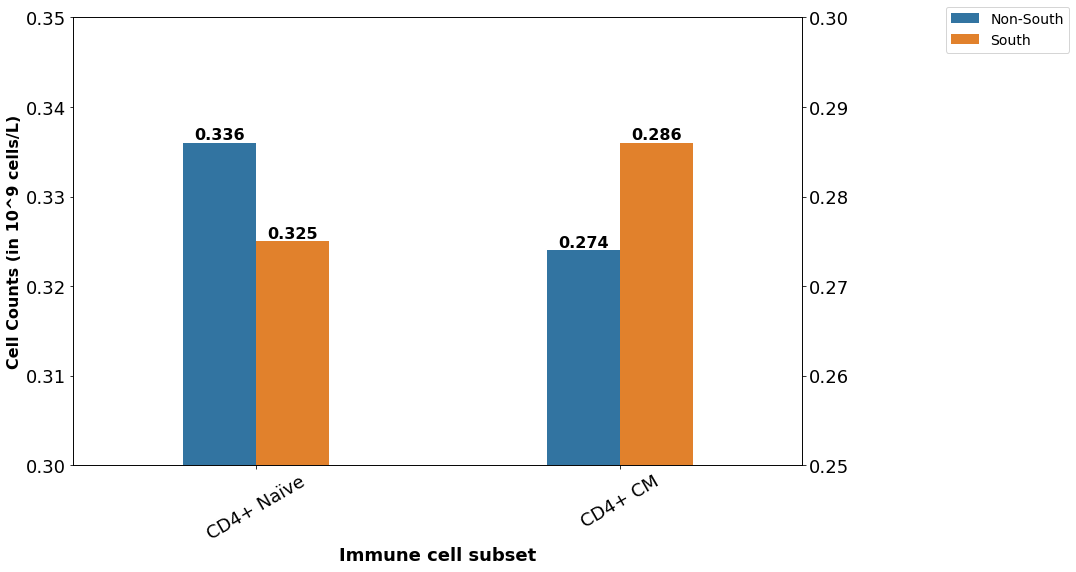

In [76]:
cd4_subset = current_results.loc[current_results['immune_cell'].str.startswith('CD4+'), :]

# # for CD4 subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(cd4_subset , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune cell subset", fontsize=18, weight='bold')
# plt.ylabel("Cell Counts (in 10^9 cells/L)", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1))

# Split the data
cd4n_data = cd4_subset[cd4_subset['immune_cell'] == 'CD4+ Naïve']
cd4cm_data = cd4_subset[cd4_subset['immune_cell'] == 'CD4+ CM']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
cd4n_bars = sns.barplot(data=cd4n_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Cell Counts (in 10^9 cells/L)", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(0.3, 0.35) 

# Annotate values on top of CD4/CD8 < 1 bars
for bar in cd4n_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Create twin axis for IHG > 1
ax2 = ax.twinx()
cd4cm_bars = sns.barplot(data=cd4cm_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(0.25, 0.3) 

# Annotate values on top of IHG > 1 bars
for bar in cd4cm_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles1, labels1, loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

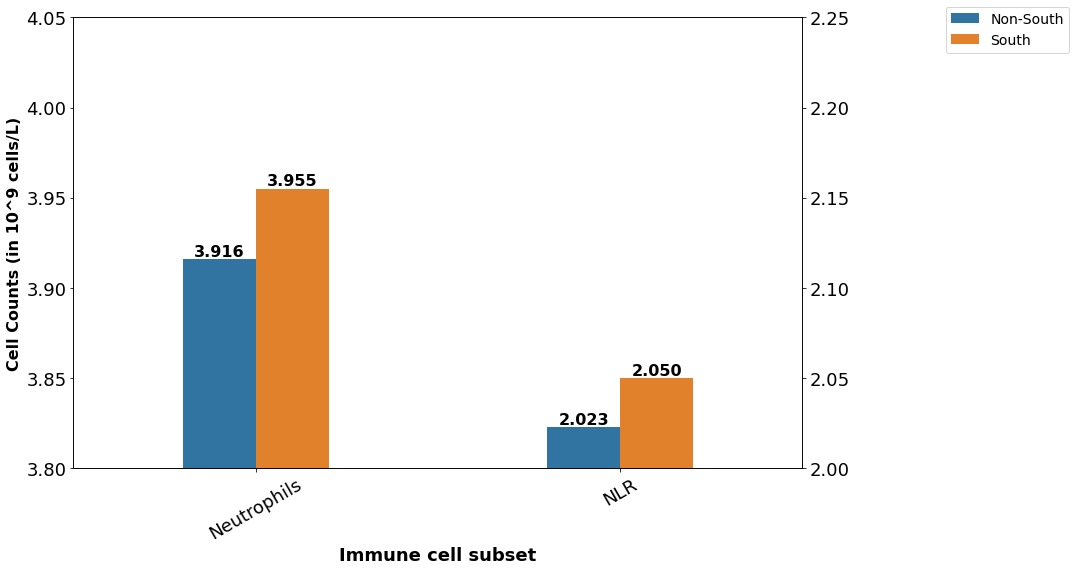

In [78]:
neut = current_results.loc[current_results['immune_cell'].isin(['Neutrophils', 'NLR']), :]

# # for neut subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(neut , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune cell subset", fontsize=18, weight='bold')
# plt.ylabel("Cell Counts (in 10^9 cells/L)", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1))

# Split the data
neut_data = neut[neut['immune_cell'] == 'Neutrophils']
nlr_data = neut[neut['immune_cell'] == 'NLR']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
neut_bars = sns.barplot(data=neut_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Cell Counts (in 10^9 cells/L)", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(3.8, 4.05) 

# Annotate values on top of CD4/CD8 < 1 bars
for bar in neut_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Create twin axis for IHG > 1
ax2 = ax.twinx()
nlr_bars = sns.barplot(data=nlr_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(2, 2.25) 

# Annotate values on top of IHG > 1 bars
for bar in nlr_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles1, labels1, loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

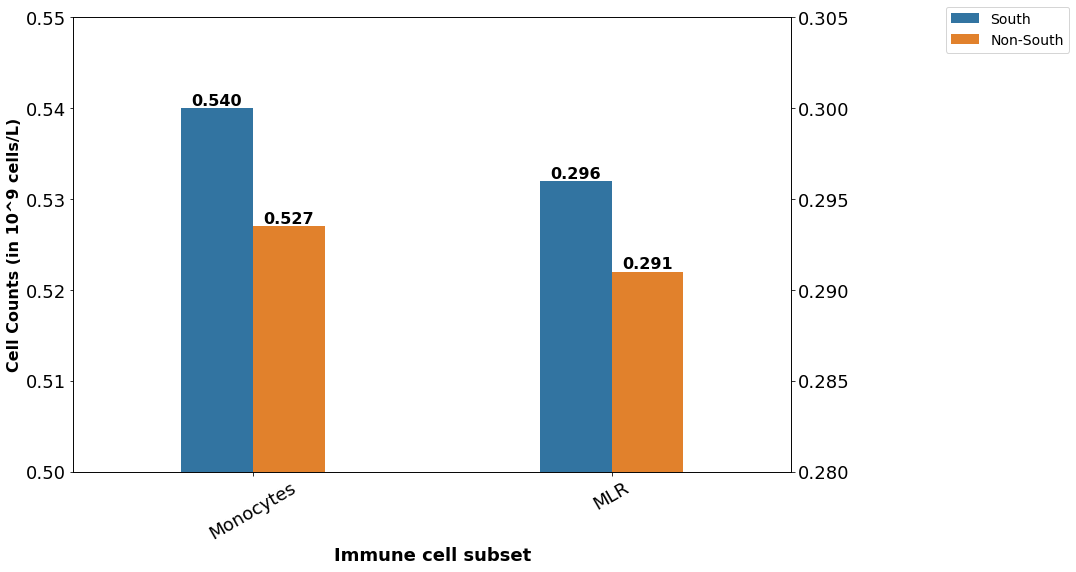

In [ ]:
mono = current_results.loc[current_results['immune_cell'].isin(['Monocytes', 'MLR']), :]

# # for mono subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(mono , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune cell subset", fontsize=18, weight='bold')
# plt.ylabel("Cell Counts (in 10^9 cells/L)", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1))

# Split the data
mono_data = mono[mono['immune_cell'] == 'Monocytes']
mlr_data = mono[mono['immune_cell'] == 'MLR']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
mono_bars = sns.barplot(data=mono_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Cell Counts (in 10^9 cells/L)", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(0.5, 0.55) 

# Annotate values on top of CD4/CD8 < 1 bars
for bar in mono_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Create twin axis for IHG > 1
ax2 = ax.twinx()
mlr_bars = sns.barplot(data=mlr_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(0.28, 0.305) 

# Annotate values on top of IHG > 1 bars
for bar in mlr_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles1, labels1, loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

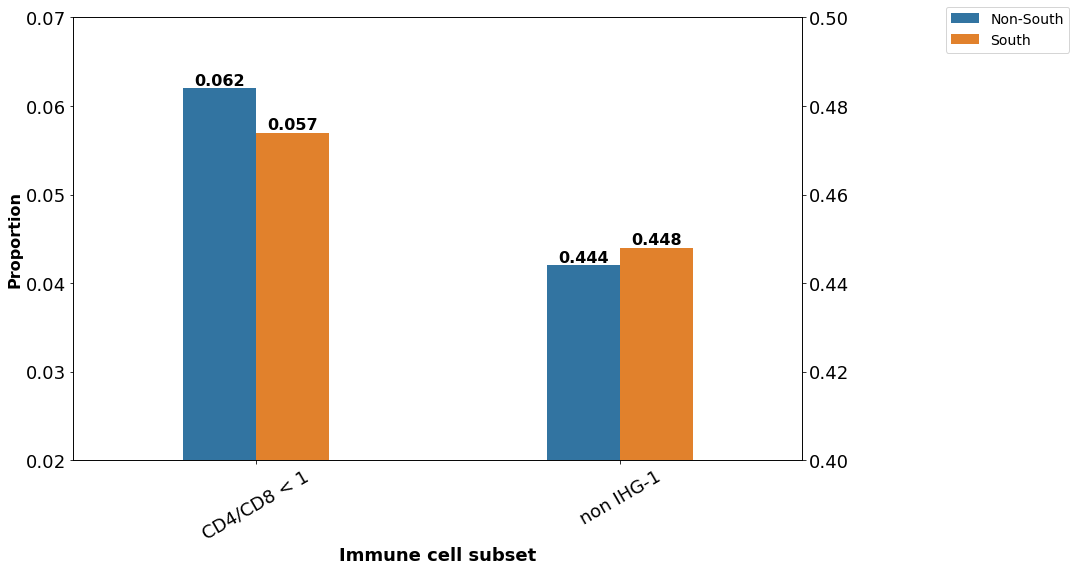

In [90]:
ARIP = current_results.loc[current_results['immune_cell'].isin(['CD4/CD8 < 1', 'non IHG-1']), :]

# # for immune phenotypes
# plt.figure(figsize=(12,8))
# ax = sns.barplot(ARIP , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune phenotype", fontsize=18, weight='bold')
# plt.ylabel("Proportion", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1))

# Split the data
cd4_cd8_data = ARIP[ARIP['immune_cell'] == 'CD4/CD8 < 1']
ihg_data = ARIP[ARIP['immune_cell'] == 'non IHG-1']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
cd4_cd8_bars = sns.barplot(data=cd4_cd8_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Proportion", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(0.02, 0.07) 

# Annotate values on top of CD4/CD8 < 1 bars
for bar in cd4_cd8_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Create twin axis for IHG > 1
ax2 = ax.twinx()
ihg_bars = sns.barplot(data=ihg_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(0.4, 0.5) 

# Annotate values on top of IHG > 1 bars
for bar in ihg_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles1, labels1, loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

### Birth Residence

In [44]:
birth_results = results_summary['Birth Residence']
birth_results

,Region,immune_cell,Mean,significance
0,Non-South,Neutrophils,3.930,NaN
1,South,Neutrophils,3.961,NaN
2,Non-South,Monocytes,0.541,NaN
3,South,Monocytes,0.529,**
4,Non-South,NLR,2.047,NaN
5,South,NLR,2.080,NaN
6,Non-South,MLR,0.300,NaN
7,South,MLR,0.296,NaN
8,Non-South,T cells,1.240,NaN
9,South,T cells,1.223,NaN


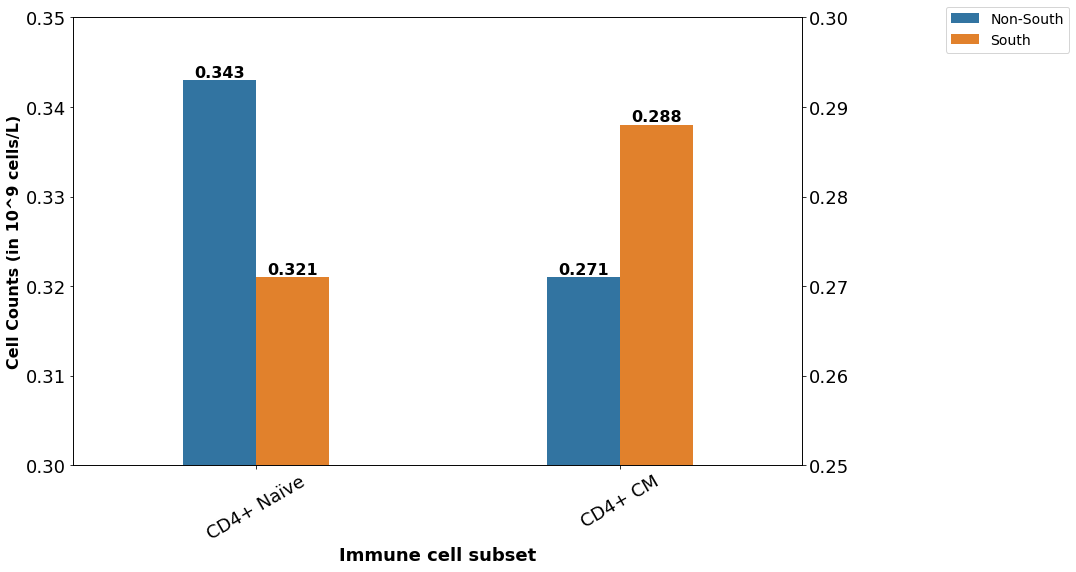

In [ ]:
cd4_subset = birth_results.loc[birth_results['immune_cell'].str.startswith('CD4+'), :]

# # for CD4 subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(cd4_subset , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune cell subset", fontsize=18, weight='bold')
# plt.ylabel("Cell Counts (in 10^9 cells/L)", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1))

# Split the data
cd4n_data = cd4_subset[cd4_subset['immune_cell'] == 'CD4+ Naïve']
cd4cm_data = cd4_subset[cd4_subset['immune_cell'] == 'CD4+ CM']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
cd4n_bars = sns.barplot(data=cd4n_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Cell Counts (in 10^9 cells/L)", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(0.3, 0.35) 

# Annotate values on top of CD4/CD8 < 1 bars
for bar in cd4n_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Create twin axis for IHG > 1
ax2 = ax.twinx()
cd4cm_bars = sns.barplot(data=cd4cm_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(0.25, 0.3) 

# Annotate values on top of IHG > 1 bars
for bar in cd4cm_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles1, labels1, loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

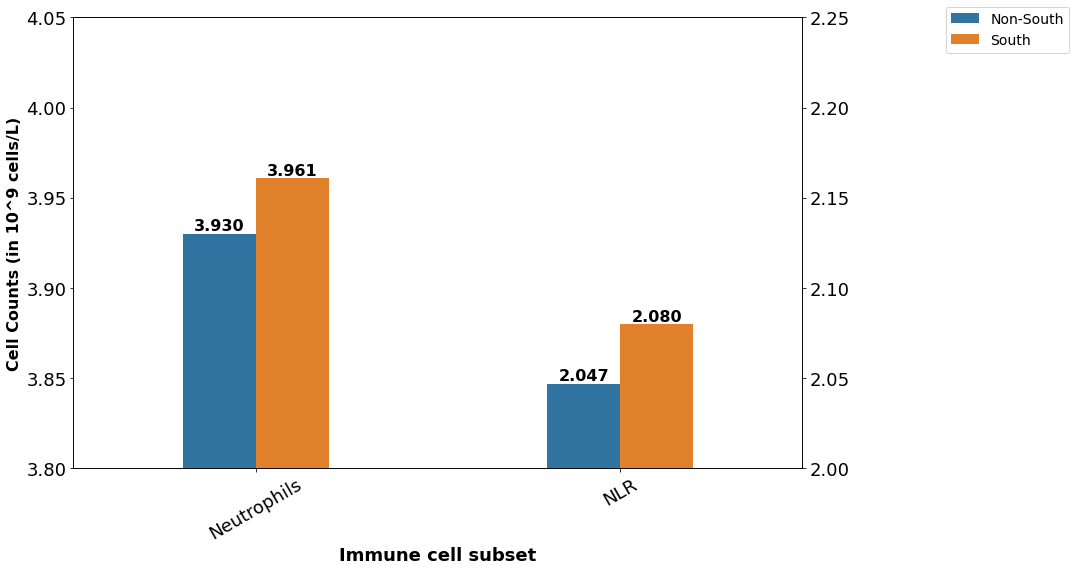

In [77]:
neut = birth_results.loc[birth_results['immune_cell'].isin(['Neutrophils', 'NLR']), :]

# # for Neut subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(neut , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune cell subset", fontsize=18, weight='bold')
# plt.ylabel("Cell Counts (in 10^9 cells/L)", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1))

# Split the data
neut_data = neut[neut['immune_cell'] == 'Neutrophils']
nlr_data = neut[neut['immune_cell'] == 'NLR']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
neut_bars = sns.barplot(data=neut_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Cell Counts (in 10^9 cells/L)", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(3.8, 4.05) 

# Annotate values on top of CD4/CD8 < 1 bars
for bar in neut_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Create twin axis for IHG > 1
ax2 = ax.twinx()
nlr_bars = sns.barplot(data=nlr_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(2, 2.25) 

# Annotate values on top of IHG > 1 bars
for bar in nlr_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles1, labels1, loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

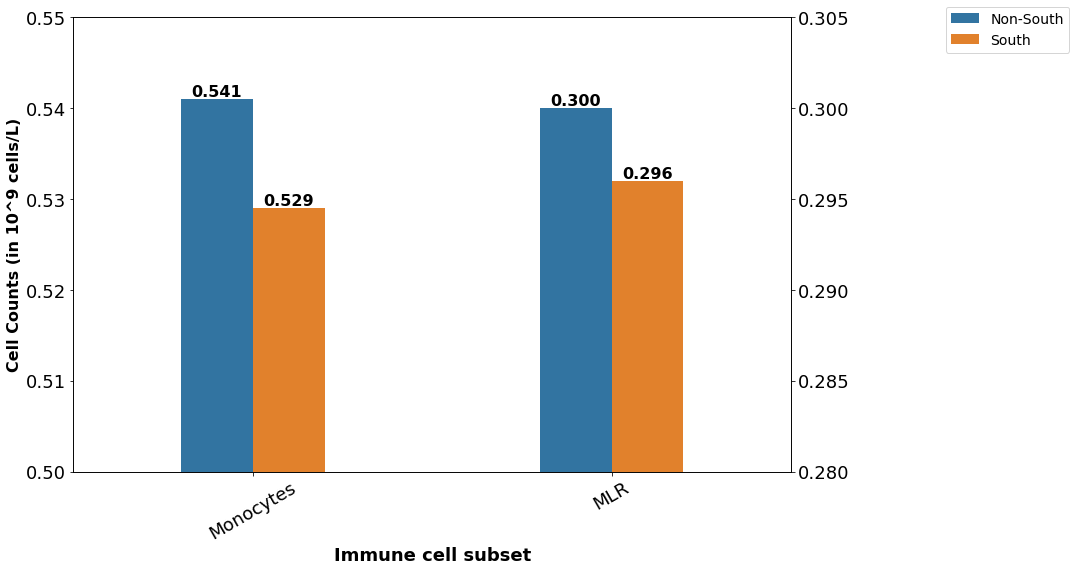

In [80]:
mono = birth_results.loc[birth_results['immune_cell'].isin(['Monocytes', 'MLR']), :]

# # for monocyte subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(mono , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune cell subset", fontsize=18, weight='bold')
# plt.ylabel("Cell Counts (in 10^9 cells/L)", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1))

# Split the data
mono_data = mono[mono['immune_cell'] == 'Monocytes']
mlr_data = mono[mono['immune_cell'] == 'MLR']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
mono_bars = sns.barplot(data=mono_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Cell Counts (in 10^9 cells/L)", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(0.5, 0.55) 

# Annotate values on top of CD4/CD8 < 1 bars
for bar in mono_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Create twin axis for IHG > 1
ax2 = ax.twinx()
mlr_bars = sns.barplot(data=mlr_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(0.28, 0.305) 

# Annotate values on top of IHG > 1 bars
for bar in mlr_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles1, labels1, loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

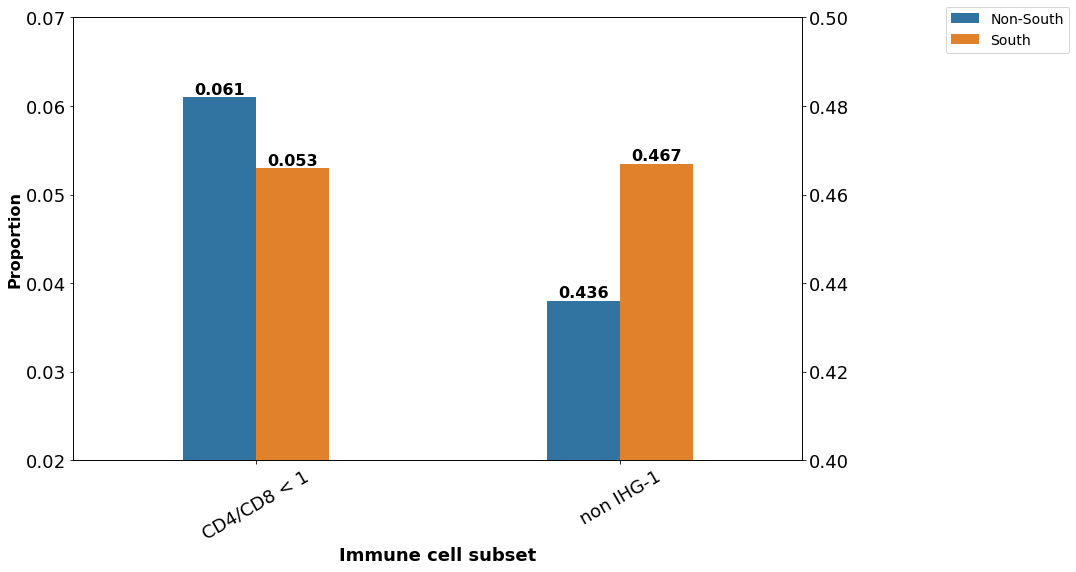

In [89]:
ARIP = birth_results.loc[birth_results['immune_cell'].isin(['CD4/CD8 < 1', 'non IHG-1']), :]

# # for immune phenotypes subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(ARIP , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune phenotype", fontsize=18, weight='bold')
# plt.ylabel("Proportion", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1))

# Split the data
cd4_cd8_data = ARIP[ARIP['immune_cell'] == 'CD4/CD8 < 1']
ihg_data = ARIP[ARIP['immune_cell'] == 'non IHG-1']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
cd4_cd8_bars = sns.barplot(data=cd4_cd8_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Proportion", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(0.02, 0.07) 

# Annotate values on top of CD4/CD8 < 1 bars
for bar in cd4_cd8_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Create twin axis for IHG > 1
ax2 = ax.twinx()
ihg_bars = sns.barplot(data=ihg_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(0.4, 0.5) 

# Annotate values on top of IHG > 1 bars
for bar in ihg_bars.containers:
    for rect in bar:
        height = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=16,
            weight='bold'
        )

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles1, labels1, loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

### Relocation

In [8]:
Relocation = results_summary['Relocation']
Relocation

,Region,immune_cell,Mean,significance
0,NS Stayer,Neutrophils,3.922,NaN
1,NS to South Mover,Neutrophils,3.958,NaN
2,South to NS Mover,Neutrophils,3.911,NaN
3,South Stayer,Neutrophils,3.972,*
4,NS Stayer,Monocytes,0.542,NaN
5,NS to South Mover,Monocytes,0.536,NaN
6,South to NS Mover,Monocytes,0.549,NaN
7,South Stayer,Monocytes,0.524,*
8,NS Stayer,NLR,2.049,NaN
9,NS to South Mover,NLR,2.039,NaN


In [40]:
cd4_subset['immune_cell'].value_counts()

immune_cell
CD4+ Naïve    4
CD4+ EM       4
CD4+ CM       4
Name: count, dtype: int64

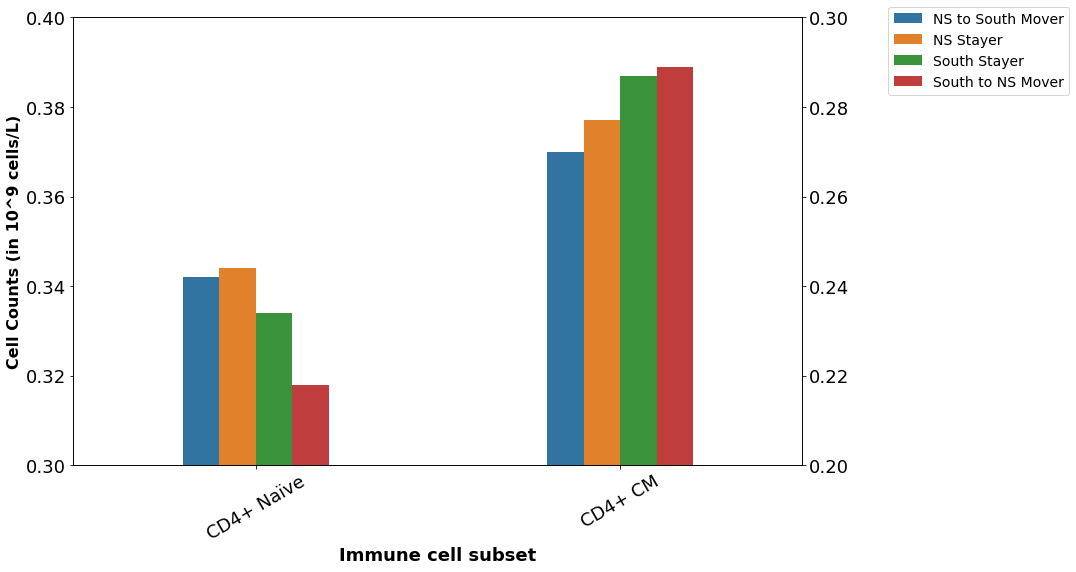

In [45]:
cd4_subset = Relocation.loc[Relocation['immune_cell'].str.startswith('CD4+'), :]

# # for CD4 subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(cd4_subset , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune cell subset", fontsize=18, weight='bold')
# plt.ylabel("Cell Counts (in 10^9 cells/L)", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.35, 1))

# # Set up figure and axes
# fig, ax = plt.subplots(figsize=(12, 8))

# Split the data
cd4n_data = cd4_subset[cd4_subset['immune_cell'] == 'CD4+ Naïve']
cd4cm_data = cd4_subset[cd4_subset['immune_cell'] == 'CD4+ CM']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
sns.barplot(data=cd4n_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Cell Counts (in 10^9 cells/L)", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(0.3, 0.4) 

# Create twin axis for IHG > 1
ax2 = ax.twinx()
sns.barplot(data=cd4cm_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(0.2, 0.3) 

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles[:len(set(labels))], list(set(labels)), loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

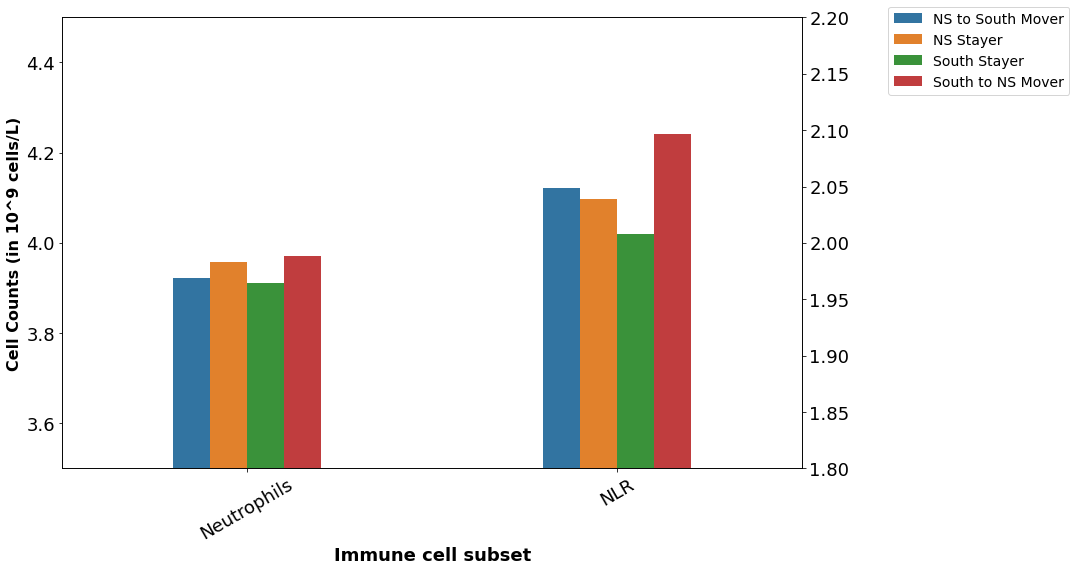

In [38]:
neut = Relocation.loc[Relocation['immune_cell'].isin(['Neutrophils', 'NLR']), :]

# # for Neut subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(neut , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune cell subset", fontsize=18, weight='bold')
# plt.ylabel("Cell Counts (in 10^9 cells/L)", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.35, 1))

# Split the data
neut_data = neut[neut['immune_cell'] == 'Neutrophils']
nlr_data = neut[neut['immune_cell'] == 'NLR']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
sns.barplot(data=neut_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Cell Counts (in 10^9 cells/L)", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(3.5, 4.5) 

# Create twin axis for IHG > 1
ax2 = ax.twinx()
sns.barplot(data=nlr_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(1.8, 2.2) 

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles[:len(set(labels))], list(set(labels)), loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

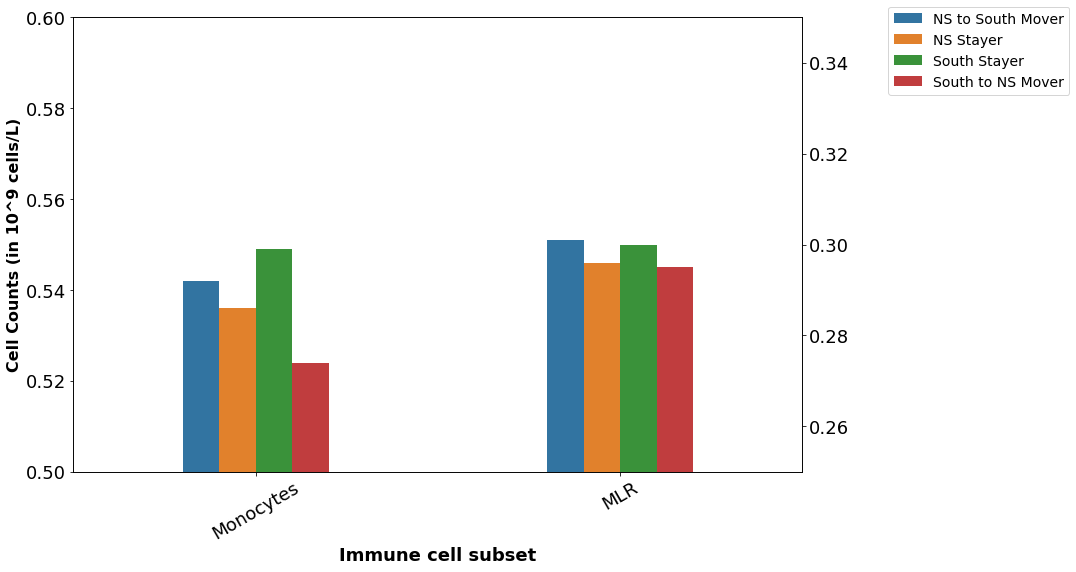

In [29]:
mono = Relocation.loc[Relocation['immune_cell'].isin(['Monocytes', 'MLR']), :]

# # for monocyte subsets
# plt.figure(figsize=(12,8))
# ax = sns.barplot(mono , x="immune_cell", y="Mean", hue="Region", width=0.5)
# plt.xlabel("Immune cell subset", fontsize=18, weight='bold')
# plt.ylabel("Cell Counts (in 10^9 cells/L)", fontsize=18, weight='bold')
# plt.xticks(fontsize=18, rotation=30)
# plt.yticks(fontsize=18)
# sns.move_legend(ax, "upper right", bbox_to_anchor=(1.35, 1))

# Split the data
mono_data = mono[mono['immune_cell'] == 'Monocytes']
mlr_data = mono[mono['immune_cell'] == 'MLR']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
sns.barplot(data=mono_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Cell Counts (in 10^9 cells/L)", fontsize=16, weight='bold')
ax.set_xlabel("Immune cell subset", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(0.5, 0.6) 

# Create twin axis for IHG > 1
ax2 = ax.twinx()
sns.barplot(data=mlr_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(0.25, 0.35) 

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles[:len(set(labels))], list(set(labels)), loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

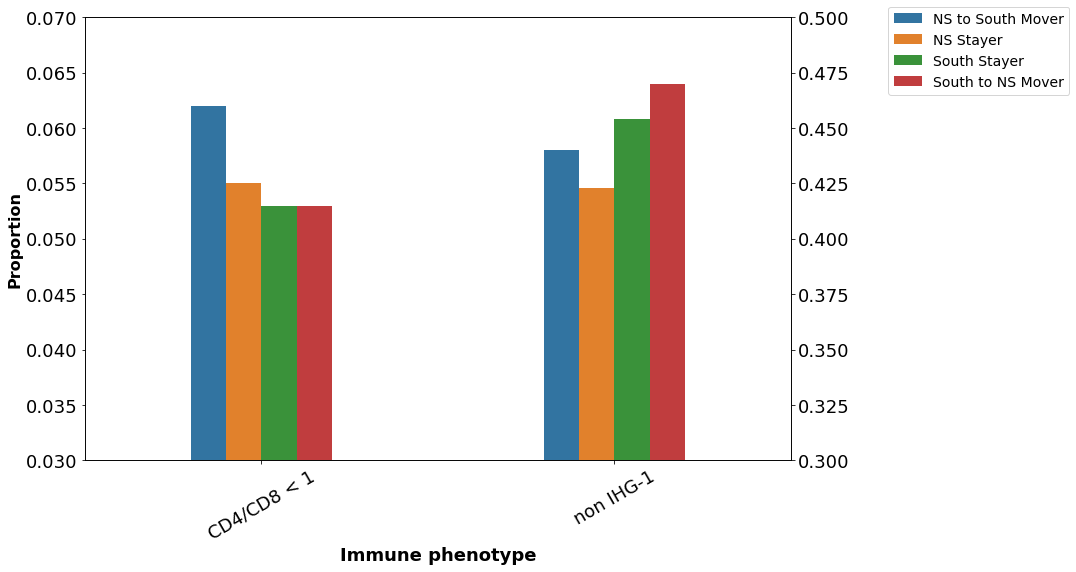

In [33]:
ARIP = Relocation.loc[Relocation['immune_cell'].isin(['CD4/CD8 < 1', 'non IHG-1']), :]

# Split the data
cd4_data = ARIP[ARIP['immune_cell'] == 'CD4/CD8 < 1']
ihg_data = ARIP[ARIP['immune_cell'] == 'non IHG-1']

# Set up figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CD4/CD8 > 1 on left axis
sns.barplot(data=cd4_data, x="immune_cell", y="Mean", hue="Region", ax=ax, width=0.4)
ax.set_ylabel("Proportion", fontsize=16, weight='bold')
ax.set_xlabel("Immune phenotype", fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18, rotation=30)
ax.set_ylim(0.03, 0.07) 

# Create twin axis for IHG > 1
ax2 = ax.twinx()
sns.barplot(data=ihg_data, x="immune_cell", y="Mean", hue="Region", ax=ax2, width=0.4, dodge=True)
ax2.set_ylabel("", fontsize=18, weight='bold')
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(0.3, 0.5) 

# Remove duplicate legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend().remove()
ax2.legend().remove()

# Combine legend manually
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles[:len(set(labels))], list(set(labels)), loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=14)

plt.title("", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()